# Servicios Web y APIs 

## Índice
1. [API Air Quality](#air)
2. [API de OpenWeather](#wea)
3. [API de la NASA](#nasa)
4. [Yahoo Finance](#yah)

En este Notebook vamos a llamar a diversas APIs. Antes de comenzar, es importante destacar dos conceptos:  

1) **Codificación de URLs**: Toda cadena de cadena de caracteres que se introduzca en una URL tiene que codificarse adecuadamente. En Python, podemos utilizar la función `quote()` del paquete `urllib.parse`

In [2]:
import urllib.parse
urllib.parse.quote(' ')

'%20'

2) **Peticiones HTTP**: la librería `requests` es la más utilizada para realizar peticiones HTTP en Python, permitiendo utilizar los métodos más comunes de este protocolo (GET, POST, PUT, etc.). Para más información entra en este [enlace](https://realpython.com/python-requests/)

También podemos utilizar la librería `urllib.request`

<a id="air"></a>
## API Air Quality

Esta API abierta proporciona información acerca de la calidad del aire en diversas ciudades. La lista de APIS se encuentra en https://api.openaq.org/  

En primer lugar vamos a llamar a la API **cities**, la cual nos informa de las ciudades disponibles

In [7]:
import urllib.request
import json

endpoint = 'https://api.openaq.org/v3/locations'
pais = input('Introduzca las siglas del país (por ejemplo ES): ')

url = endpoint + '?country=' + pais
print(url)

datos = urllib.request.urlopen(url,
                            ).read().decode()

js = json.loads(datos)

for item in js['results']:
    print(item['city'])

https://api.openaq.org/v3/locations?country=ES


HTTPError: HTTP Error 401: Unauthorized

Esto mismo podemos realizarlo con la librería `requests`, instalándola previamente.  
Esta librería también me permite utilizar el método POST de HTTP: `requests.post(...)`

In [10]:
import requests

endpoint = 'https://api.openaq.org/v3/locations'
pais = input('Introduzca las siglas del país (por ejemplo ES): ')

API_key = '1de0002d735478ecfd3e5e2b15198b7b8611e0f74bcef893af74e32ed9502345'

# Usar parámetros para obtener más resultados
datos = requests.get(endpoint, params={'code': pais, 'limit': 1000}, headers={'X-API-KEY': API_key})

if datos.status_code == 200:
    js = datos.json()
    
    # Extraer ciudades únicas
    ciudades = set()
    for item in js['results']:
        if 'city' in item and item['city']:
            ciudades.add(item['city'])
    
    print(f"Ciudades encontradas en {pais}:")
    for ciudad in sorted(ciudades):
        print(f"- {ciudad}")
else:
    print(f"Error: {datos.status_code}")

Ciudades encontradas en ES:


In [8]:
datos

<Response [404]>

A continuación, llamamos a la API **latest**, que devuelve los últimos registros de una ciudad o país en concreto

In [17]:
ciudad = input('Introduzca el nombre de la ciudad: ')
endpoint = 'https://api.openaq.org/v2/latest'

url = endpoint + '?city=' + urllib.parse.quote(ciudad) + '&limit=1&country=ES' 
print(url)

datos = urllib.request.urlopen(url).read().decode()
js = json.loads(datos)

Introduzca el nombre de la ciudad: A Coruña
https://api.openaq.org/v2/latest?city=A%20Coru%C3%B1a&limit=1&country=ES


Parseamos el JSON de respuesta para obtener todos los niveles disponibles y la fecha de las mediciones

In [18]:
# El valor de xxx en Madrid a fecha de yyy es de zzz unidades"
for item in js['results'][0]['measurements']:
    print('El valor de', item['parameter'], 'en', ciudad, 'a fecha de',
          item['lastUpdated'], 'es de', item['value'], item['unit'])


El valor de co en A Coruña a fecha de 2023-10-24T03:00:00+00:00 es de 0.0 ppm
El valor de pm10 en A Coruña a fecha de 2023-10-24T03:00:00+00:00 es de 31.0 µg/m³
El valor de no2 en A Coruña a fecha de 2023-10-24T03:00:00+00:00 es de 0.031 ppm


<a id="wea"></a>
## API de OpenWeather

Esta API permite obtener información climática. Puedes encontrar la documentación en https://openweathermap.org/api.   
Para obtener la API key hay que registrar un email válido, al cual será enviada la clave.  

Vamos a obtener la predicción de velocidad del viento para una ciudad a través de [esta API](https://openweathermap.org/forecast5)

In [16]:
import urllib.parse
import urllib.request
import json

api_key = '3886d5996f84c5b9a5c953b027fc2306'

ciudad = input('Introuzca una ciudad y un código de país separados por coma: ')

url = 'https://api.openweathermap.org/data/2.5/forecast?q=' + urllib.parse.quote(ciudad) + '&appid=' + api_key
print(url)

datos = urllib.request.urlopen(url).read().decode()
js = json.loads(datos)

ts = []
speed = []
# Vamos a añadir la temperatura
temp = []

for item in js['list']:
    ts.append(item['dt_txt'])
    speed.append(item['wind']['speed'])
    temp.append(item['main']['temp'])
    
# convertir de Kelvin a Celsius
temp = [t - 273 for t in temp]

https://api.openweathermap.org/data/2.5/forecast?q=Alicante%2CES&appid=3886d5996f84c5b9a5c953b027fc2306


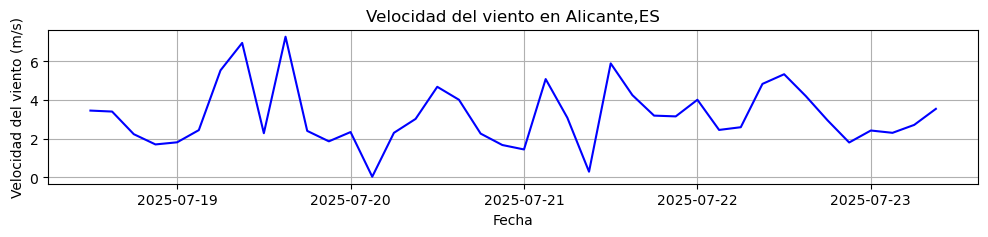

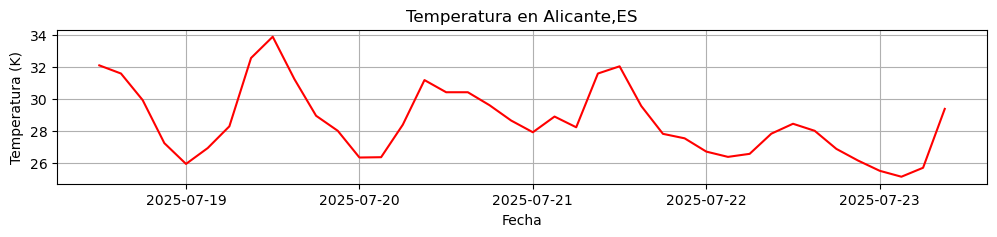

In [17]:
from datetime import datetime
import matplotlib.pyplot as plt

ts2 = [datetime.strptime(d,'%Y-%m-%d %H:%M:%S') for d in ts]
fig = plt.figure(figsize=(12,2))
plt.grid()
plt.plot(ts2,speed,color='blue', label='Velocidad del viento')
plt.title('Velocidad del viento en ' + ciudad)
plt.xlabel('Fecha')
plt.ylabel('Velocidad del viento (m/s)')
plt.show()

# Representación de la temperatura
fig = plt.figure(figsize=(12,2))
plt.grid()
plt.plot(ts2, temp, color='red', label='Temperatura')
plt.title('Temperatura en ' + ciudad)
plt.xlabel('Fecha')
plt.ylabel('Temperatura (K)')
plt.show()

<a id="nasa"></a>
## API de la NASA
[Documentación](https://api.nasa.gov/)  
Vamos a obtener fotos de marte a través de la API "Mars Rover Photos" del día 01/09/2022

In [1]:
import requests

endpoint = 'https://api.nasa.gov/mars-photos/api/v1/rovers/curiosity/photos'
res = requests.get(endpoint, params={'earth_date':'2022-09-01',
                                    'api_key':'DEMO_KEY'})



In [3]:
print(res.text)

{"photos":[{"id":1024497,"sol":3580,"camera":{"id":20,"name":"FHAZ","rover_id":5,"full_name":"Front Hazard Avoidance Camera"},"img_src":"https://mars.nasa.gov/msl-raw-images/proj/msl/redops/ods/surface/sol/03580/opgs/edr/fcam/FLB_715310011EDR_F0971170FHAZ00302M_.JPG","earth_date":"2022-09-01","rover":{"id":5,"name":"Curiosity","landing_date":"2012-08-06","launch_date":"2011-11-26","status":"active"}},{"id":1024498,"sol":3580,"camera":{"id":20,"name":"FHAZ","rover_id":5,"full_name":"Front Hazard Avoidance Camera"},"img_src":"https://mars.nasa.gov/msl-raw-images/proj/msl/redops/ods/surface/sol/03580/opgs/edr/fcam/FRB_715310011EDR_F0971170FHAZ00302M_.JPG","earth_date":"2022-09-01","rover":{"id":5,"name":"Curiosity","landing_date":"2012-08-06","launch_date":"2011-11-26","status":"active"}},{"id":1024499,"sol":3580,"camera":{"id":21,"name":"RHAZ","rover_id":5,"full_name":"Rear Hazard Avoidance Camera"},"img_src":"https://mars.nasa.gov/msl-raw-images/proj/msl/redops/ods/surface/sol/03580/opg

In [4]:
foto_url = res.json()['photos'][0]['img_src']
print(foto_url)

https://mars.nasa.gov/msl-raw-images/proj/msl/redops/ods/surface/sol/03580/opgs/edr/fcam/FLB_715310011EDR_F0971170FHAZ00302M_.JPG


In [5]:
from IPython.display import Image

display(Image(url=foto_url))

## <span style="color:red">Do it yourself</span>
¿Dónde está la Estación Espacial Internacional? Utilizando [esta API](https://wheretheiss.at/w/developer), comprueba que se está moviendo

<a id="yah"></a>
## Yahoo Finance
Muchas veces, usamos APIs a través de librerías de Python. Por ejemplo, la librería `yfinance` permite conectarnos a la API de Yahoo finance. Puedes encontrar la documentación en [este enlace](https://aroussi.com/post/python-yahoo-finance)

In [42]:
!pip install yfinance

  Obtaining dependency information for yfinance from https://files.pythonhosted.org/packages/e6/b3/388ab967a387cc92926f70e97688dd9a7189b29a0773db815ffc5289e2b5/yfinance-0.2.31-py2.py3-none-any.whl.metadata
  Using cached multitasking-0.0.11-py3-none-any.whl (8.5 kB)
  Using cached appdirs-1.4.4-py2.py3-none-any.whl (9.6 kB)
     ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
      --------------------------------------- 0.0/2.9 MB 991.0 kB/s eta 0:00:03
     - -------------------------------------- 0.1/2.9 MB 1.7 MB/s eta 0:00:02
     ---- ----------------------------------- 0.3/2.9 MB 2.5 MB/s eta 0:00:02
     ----- ---------------------------------- 0.4/2.9 MB 3.0 MB/s eta 0:00:01
     ------ --------------------------------- 0.5/2.9 MB 2.5 MB/s eta 0:00:01
     -------- ------------------------------- 0.6/2.9 MB 2.5 MB/s eta 0:00:01
     --------- ------------------------------ 0.7/2.9 MB 2.3 MB/s eta 0:00:01
     ---------- ----------------------------- 0.8/2.9 M

In [43]:
import yfinance as yf

In [46]:
data = yf.download('MSFT', period='5d', interval='1m')
data

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Datetime,,,,,,
2023-10-17 09:30:00-04:00,329.589996,329.980011,329.100006,329.500000,329.500000,809355
2023-10-17 09:31:00-04:00,329.500000,329.540009,328.820007,329.440002,329.440002,136453
2023-10-17 09:32:00-04:00,329.399994,330.415009,329.000000,330.290009,330.290009,104449
2023-10-17 09:33:00-04:00,330.239990,330.239990,329.600006,329.765015,329.765015,85866
2023-10-17 09:34:00-04:00,329.799988,329.859985,329.450012,329.744995,329.744995,61679
...,...,...,...,...,...,...
2023-10-23 13:30:00-04:00,331.540009,331.619995,331.230011,331.339996,331.339996,43442
2023-10-23 13:31:00-04:00,331.420013,331.670013,331.365906,331.619995,331.619995,26953
2023-10-23 13:32:00-04:00,331.660004,331.760010,331.529999,331.720001,331.720001,27140


In [47]:
data2 = yf.download('AAPL', period='5d', interval='1m')
data2

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Datetime,,,,,,
2023-10-17 09:30:00-04:00,176.645004,176.970001,176.500000,176.970001,176.970001,2299597
2023-10-17 09:31:00-04:00,176.955002,176.990005,176.429901,176.570007,176.570007,404346
2023-10-17 09:32:00-04:00,176.559998,176.839996,176.464996,176.727997,176.727997,264222
2023-10-17 09:33:00-04:00,176.714996,176.720001,176.190002,176.205002,176.205002,358915
2023-10-17 09:34:00-04:00,176.210007,176.330002,175.940002,176.190002,176.190002,459076
...,...,...,...,...,...,...
2023-10-23 13:30:00-04:00,173.300003,173.360001,173.210007,173.235001,173.235001,124334
2023-10-23 13:31:00-04:00,173.259995,173.410004,173.259995,173.369995,173.369995,56469
2023-10-23 13:32:00-04:00,173.391907,173.429993,173.330002,173.419998,173.419998,72696


In [51]:
data3 = data.merge(data2,left_index=True, right_index=True)
data3[['Close_x','Close_y']].corr()

,Close_x,Close_y
Close_x,1.000000,0.782922
Close_y,0.782922,1.000000
